In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
import seaborn as sns

In [40]:
import os
os.getcwd()

'/Users/megan/Desktop/crime-patterns-and-urban-design/notebooks'

In [41]:
lou_crime = pd.read_csv('../data/lmpd_crime.csv')

In [42]:
lou_crime.head()

,incident_number,date_reported,date_occurred,badge_id,offense_classification,offense_code_name,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ObjectId
0,LMPD25080477,7/11/2025 3:29:00 PM,5/10/2024 4:00:00 AM,2469.0,29 FRAUD IMPERSONATION,THEFT OF IDENTITY OF ANOTHER WITHOUT CONSENT 5...,26C,A,YES,2ND DIVISION,211,RESIDENCE/HOME,600 BLOCK S 44TH ST,LOUISVILLE,40211,1
1,LMPD25007349,1/23/2025 5:14:00 PM,12/15/2024 3:40:00 PM,8611.0,19 THEFT FR BLDG,TBUT OR DISP FROM BUILDING 514.030 24160 23D,23D,A,YES,4TH DIVISION,412,RESIDENCE/HOME,900 BLOCK S BROOK ST,LOUISVILLE,40203,2
2,LMPD25077420,7/5/2025 5:42:00 PM,11/1/2024 4:00:00 AM,7090.0,13 BURGLARY,BURGLARY - 2ND DEGREE 511.030 22061 220,220,A,YES,7TH DIVISION,736,RESIDENCE/HOME,1000 BLOCK MEADOW HILL RD,LOUISVILLE,40219,3
3,LMPD25067785,6/13/2025 11:18:00 PM,9/15/2024 4:00:00 PM,8544.0,23 LARCENY,TBUT OR DISP ALL OTHERS 514.030 24095 23H,23H,A,YES,5TH DIVISION,521,INDUSTRIAL SITE,2600 BLOCK BUDDEKE DR,LOUISVILLE,40206,4
4,LMPD25007340,1/23/2025 4:48:00 PM,3/1/2024 5:01:00 AM,8358.0,29 FRAUD IMPERSONATION,THEFT OF IDENTITY OF ANOTHER WITHOUT CONSENT 5...,26C,A,YES,2ND DIVISION,223,RESIDENCE/HOME,3300 BLOCK KIRBY AVE,LOUISVILLE,40211,5


In [43]:
lou_crime.columns

Index(['incident_number', 'date_reported', 'date_occurred', 'badge_id',
       'offense_classification', 'offense_code_name', 'nibrs_code',
       'nibrs_group_name', 'was_offense_completed', 'lmpd_division',
       'lmpd_beat', 'location_category', 'block_address', 'city', 'zip_code',
       'ObjectId'],
      dtype='object')

##### Drop Columns
Dropped columns date_reported, badge_id, and ObjectId because they added no meaningful data for my project and weren't necessary for tracking data either.

In [44]:
lou_crime = lou_crime.drop(columns=['date_reported', 'badge_id', 'ObjectId'])

In [45]:
lou_crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70746 entries, 0 to 70745
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   incident_number         70746 non-null  object
 1   date_occurred           70746 non-null  object
 2   offense_classification  70615 non-null  object
 3   offense_code_name       70744 non-null  object
 4   nibrs_code              70746 non-null  object
 5   nibrs_group_name        70746 non-null  object
 6   was_offense_completed   70746 non-null  object
 7   lmpd_division           70501 non-null  object
 8   lmpd_beat               70465 non-null  object
 9   location_category       70705 non-null  object
 10  block_address           69634 non-null  object
 11  city                    70746 non-null  object
 12  zip_code                70740 non-null  object
dtypes: object(13)
memory usage: 7.0+ MB


In [46]:
lou_crime.shape

(70746, 13)

In [47]:
lou_crime.value_counts()

incident_number  date_occurred          offense_classification  offense_code_name                                                  nibrs_code  nibrs_group_name  was_offense_completed  lmpd_division  lmpd_beat  location_category                       block_address              city        zip_code
LMPD24038714     4/4/2024 3:00:00 AM    24 VANDALISM            CRIMINAL MISCHIEF-2ND DEGREE 512.030 01402 290                     290         A                 YES                    1ST DIVISION   123        PARKING/ DROP LOT/ GARAGE               100 BLOCK S 6TH ST         LOUISVILLE  40202       4
LMPD24112481     9/25/2024 6:00:00 PM   24 VANDALISM            CRIMINAL MISCHIEF - 1ST DEGREE 512.020 01401 290                   290         A                 YES                    3RD DIVISION   322        RESIDENCE/HOME                          5300 BLOCK MITSCHER AVE    LOUISVILLE  40214       3
LMPD24088355     7/31/2024 1:30:00 AM   13 BURGLARY             BURGLARY - 3RD DEGREE 511.040 22

In [48]:
lou_crime.isnull().sum() * 100 / len(lou_crime)

incident_number           0.000000
date_occurred             0.000000
offense_classification    0.185169
offense_code_name         0.002827
nibrs_code                0.000000
nibrs_group_name          0.000000
was_offense_completed     0.000000
lmpd_division             0.346309
lmpd_beat                 0.397196
location_category         0.057954
block_address             1.571820
city                      0.000000
zip_code                  0.008481
dtype: float64

In [49]:
lou_crime[lou_crime['block_address'].isna()]

,incident_number,date_occurred,offense_classification,offense_code_name,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code
141,LMPD25002561,10/2/2024 4:00:00 AM,22 THEFT MV PARTS,THEFT OF MOTOR VEHICLE REGISTRATION PLATE/DECA...,23G,A,YES,2ND DIVISION,223,PARKING/ DROP LOT/ GARAGE,NaN,LOUISVILLE,40210
250,LMPD25094869,7/5/2024 6:00:00 AM,24 VANDALISM,CRIMINAL MISCHIEF-2ND DEGREE 512.030 01402 290,290,A,YES,2ND DIVISION,223,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,NaN,LOUISVILLE,40211
251,LMPD25094869,7/5/2024 6:00:00 AM,9 AGGRAVATED ASSAULT,WANTON ENDANGERMENT 1ST - DISCHARGE OF FIREARM...,13A,A,YES,2ND DIVISION,223,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,NaN,LOUISVILLE,40211
258,LMPD25089674,11/28/2024 12:00:00 AM,22 THEFT MV PARTS,THEFT OF MOTOR VEHICLE REGISTRATION PLATE/DECA...,23G,A,YES,2ND DIVISION,234,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,NaN,LOUISVILLE,40210
311,LMPD25009782,12/13/2024 11:00:00 PM,9 AGGRAVATED ASSAULT,WANTON ENDANGERMENT 1ST - DISCHARGE OF FIREARM...,13A,A,YES,1ST DIVISION,111,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,NaN,LOUISVILLE,40212
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70646,8023012144,11/3/2024 7:23:00 PM,33 STOLEN PROPERTY,RECEIVING STOLEN PROPERTY (FIREARM) 514.110 28...,280,A,YES,1ST DIVISION,112,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,NaN,LOUISVILLE,40203
70655,8021034150,1/10/2024 11:20:00 PM,33 STOLEN PROPERTY,RECEIVING STOLEN PROPERTY (FIREARM) 514.110 28...,280,A,YES,1ST DIVISION,111,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,NaN,LOUISVILLE,40212
70658,8021029830,4/7/2024 7:09:00 AM,33 STOLEN PROPERTY,RECEIVING STOLEN PROPERTY (FIREARM) 514.110 28...,280,A,YES,2ND DIVISION,223,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,NaN,LOUISVILLE,40210
70661,8023004987,12/27/2024 6:30:00 PM,33 STOLEN PROPERTY,RECEIVING STOLEN PROPERTY (FIREARM) 514.110 28...,280,A,YES,2ND DIVISION,212,HIGHWAY/ ROAD/ ALLEY/ STREET/ SIDEWALK,NaN,LOUISVILLE,40211


In [50]:
lou_crime.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
70741    False
70742    False
70743    False
70744    False
70745    False
Length: 70746, dtype: bool

In [51]:
cols = [
    'incident_number',
    'date_occurred',
    'offense_classification',
    'nibrs_code',
    'block_address',
    'zip_code',
    'lmpd_beat',
    'location_category',
    'was_offense_completed'
]

lou_crime = lou_crime[cols]

In [52]:
lou_crime['date_occurred'] = pd.to_datetime(lou_crime['date_occurred'])
lou_crime['month'] = lou_crime['date_occurred'].dt.month
lou_crime['day_of_week'] = lou_crime['date_occurred'].dt.day_name()
lou_crime['hour'] = lou_crime['date_occurred'].dt.hour

In [53]:
lou_crime['crime_code'] = lou_crime['nibrs_code']
lou_crime['crime_type'] = lou_crime['offense_classification']

In [54]:
lou_crime = lou_crime.drop_duplicates(subset='incident_number')
lou_crime = lou_crime.dropna(subset=['block_address', 'zip_code'])

In [55]:
lou_crime.columns

Index(['incident_number', 'date_occurred', 'offense_classification',
       'nibrs_code', 'block_address', 'zip_code', 'lmpd_beat',
       'location_category', 'was_offense_completed', 'month', 'day_of_week',
       'hour', 'crime_code', 'crime_type'],
      dtype='object')

In [56]:
value_counts_series = lou_crime['offense_classification'].value_counts()
print(value_counts_series)

offense_classification
56 ALL OTHER OFFENSES        7650
11 SIMPLE ASSAULT            5776
24 VANDALISM                 5173
14 AUTO THEFT                5133
23 THEFT OTHER               4339
21 THEFT FR VEH              3518
12 INTIMIDATION              3501
18 SHOPLIFTING               3125
13 BURGLARY                  2899
9 AGGRAVATED ASSAULT         2132
23 LARCENY                   1736
19 THEFT FR BLDG             1294
34 NARCOTICS                 1287
46 FAMILY OFFENSES           1159
22 THEFT MV PARTS            1106
28 FRAUD CREDIT CARD/ATM     1062
8 ROBBERY                     777
29 FRAUD IMPERSONATION        703
26 COUNTERFEITING             584
33 STOLEN PROPERTY            493
46 WPNS LAW VIOLATION         419
35 NARCOTICS EQUIP            379
55 TRESPASSING                371
27 FRAUD                      337
99 NON-REPORTABLE             271
4 FORCIBLE RAPE               214
32 EMBEZZLEMENT               201
7 FORCIBLE FONDLING           177
15 UNAUTHORIZED USE      

Create buckets for crimes that would affect business owner decisions, public perception of security, or rate of foot traffic

In [57]:
offense_buckets = {
    "Quality of Life / Public Disorder": [
        "24 VANDALISM",
        "18 SHOPLIFTING",
        "55 TRESPASSING",
        "51 DISORDERLY CONDUCT"
    ],

    "Property Crime": [
        "14 AUTO THEFT",
        "21 THEFT FR VEH",
        "23 THEFT OTHER",
        "19 THEFT FR BLDG",
        "13 BURGLARY",
        "23 LARCENY"
    ],

    "Interpersonal (Public-Facing)": [
        "11 SIMPLE ASSAULT",
        "9 AGGRAVATED ASSAULT",
        "8 ROBBERY",
        "12 INTIMIDATION"
    ]
}

In [58]:
#Create lookup: offense -> bucket
offense_to_bucket = {
    offense: bucket
    for bucket, offenses in offense_buckets.items()
    for offense in offenses
}

#Create new column
lou_crime['crime_bucket'] = (
    lou_crime['offense_classification']
        .map(offense_to_bucket)
        .fillna("Other / Excluded")
)

In [59]:
#Filter out unneeded crime types
analysis_df = lou_crime[
    lou_crime['crime_bucket'] != "Other / Excluded"
].copy()

In [60]:
top_zips = (
    analysis_df.groupby('zip_code')
        .size()
        .sort_values(ascending=False)
        .head(5)
        .index
)

In [61]:
analysis_df["crime_bucket"].value_counts()

crime_bucket
Property Crime                       18919
Interpersonal (Public-Facing)        12186
Quality of Life / Public Disorder     8721
Name: count, dtype: int64

In [62]:
#Aggregate by zip plus crime bucket
zip_bucket_counts = (
    analysis_df[analysis_df['zip_code'].isin(top_zips)]
        .groupby(['zip_code', 'crime_bucket'])
        .size()
        .unstack(fill_value=0)
)

#Convert counts to rates for consistency across zips
zip_bucket_rates = zip_bucket_counts.div(
    zip_bucket_counts.sum(axis=1),
    axis=0
)

In [63]:
zip_bucket_rates = zip_bucket_rates.apply(pd.to_numeric, errors="coerce")
zip_bucket_rates = zip_bucket_rates.fillna(0)

In [64]:
zip_bucket_rates.head()

crime_bucket,Interpersonal (Public-Facing),Property Crime,Quality of Life / Public Disorder
zip_code,,,
40202,0.248281,0.538213,0.213506
40203,0.343398,0.466715,0.189887
40211,0.359815,0.433475,0.206710
40214,0.329588,0.477154,0.193258
40219,0.316591,0.402207,0.281202


In [65]:
zip_bucket_rates.dtypes

crime_bucket
Interpersonal (Public-Facing)        float64
Property Crime                       float64
Quality of Life / Public Disorder    float64
dtype: object

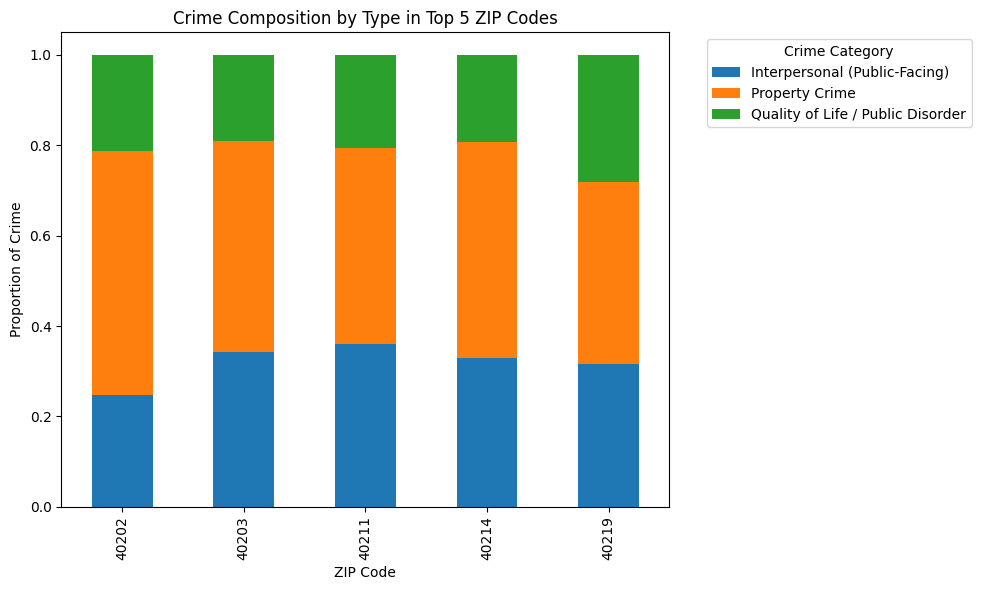

In [66]:
zip_bucket_rates.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel('Proportion of Crime')
plt.xlabel('ZIP Code')
plt.title('Crime Composition by Type in Top 5 ZIP Codes')
plt.legend(title='Crime Category', bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### Updated bar chart
Percentages are used instead of decimal points

Left, top, and right spines have been dropped

Percentages are now printed directly on bars to more clearly represent values

Values are ordered so that greatest percentage is on the bottom and so on up

Color has been assigned to individual attributes for consistency throughout charts

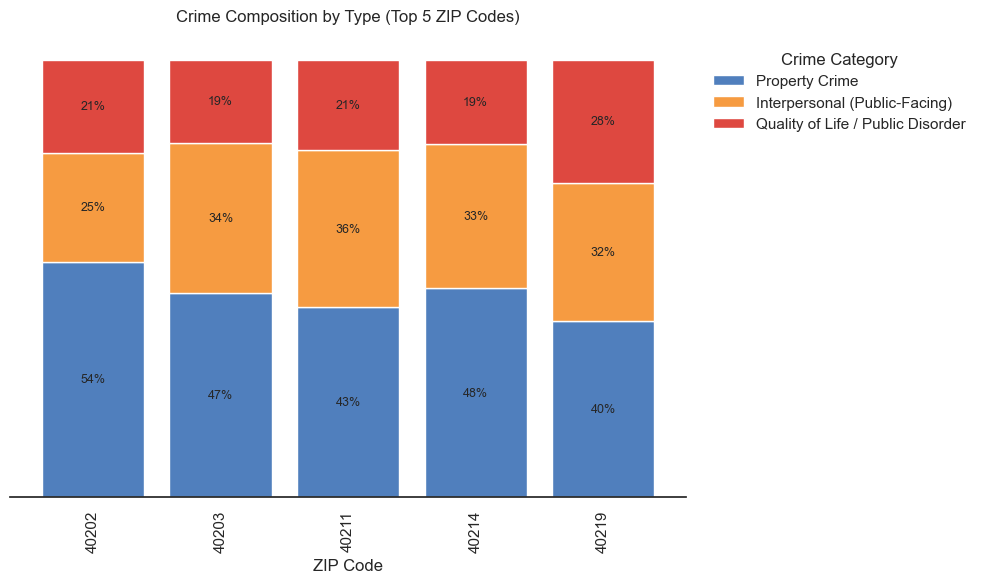

In [89]:
#Updated bar chart with percentages instead of decimal points, and largest portion from bottom to top
from matplotlib.ticker import PercentFormatter
sns.set_theme(style="white")

bucket_order = (
    zip_bucket_rates.sum()
        .sort_values(ascending=False)
        .index
)

zip_bucket_rates = zip_bucket_rates[bucket_order]

bucket_colors = {
    "Property Crime": "#507fbd",
    "Quality of Life / Public Disorder": "#de4840",
    "Interpersonal (Public-Facing)": "#f69b41"
}

fig, ax = plt.subplots(figsize=(10, 6))

zip_bucket_rates.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[bucket_colors[c] for c in zip_bucket_rates.columns],
    width=0.8
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.0%}" if v > 0.05 else "" for v in container.datavalues],
        label_type="center",
        fontsize=9
    )

ax.set_ylabel("")
ax.set_yticks([])
ax.spines["left"].set_visible(False)

ax.set_xlabel("ZIP Code")
ax.set_title("Crime Composition by Type (Top 5 ZIP Codes)", pad=12)

ax.legend(
    title="Crime Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()


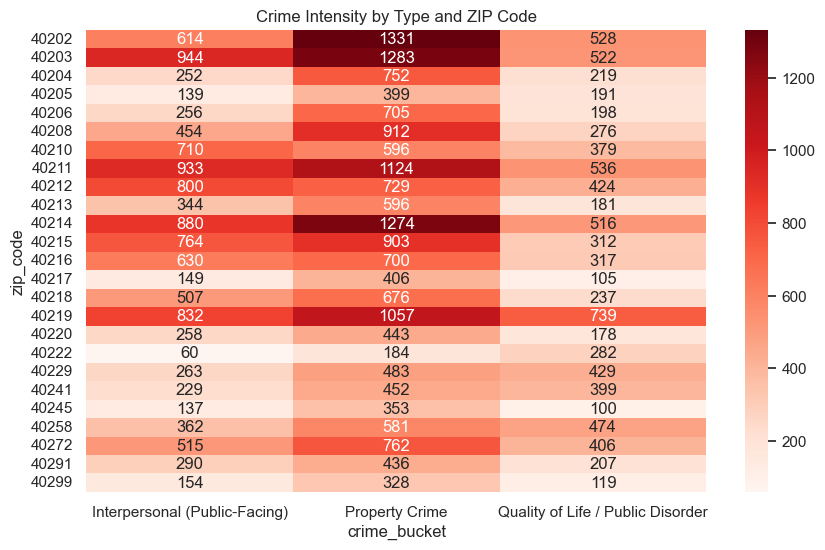

In [90]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    zip_bucket_counts,
    cmap="Reds",
    annot=True,
    fmt="d"
)
plt.title("Crime Intensity by Type and ZIP Code")
plt.show()